# 05 — Statistical Association: Passing Structure vs. Quarterfinal Advancement (2022 World Cup)

**Main question:** Do teams that reached the 2022 quarterfinals show a genuinely different passing-network profile from teams eliminated earlier — and does that signal already show up in the group stage, or is it a knockout-round artifact?

**Two analyses, in order of evidentiary weight:**
1. **Primary — team-level Mann-Whitney U (group stage, one profile per team).** 8 quarterfinalists vs. 24 non-quarterfinalists, 32 independent observations. This is the headline inferential test.
2. **Secondary / exploratory — team-match-level Mann-Whitney U** (full tournament, and group-stage only). Retained because it preserves match-to-match variation, but rows from the same team are not independent, so it is not used for the primary conclusion.

**Input:** `data/processed/team_match_network_features_normalized.csv`
**Output:** `outputs/tables/mann_whitney_team_level_2022.csv` (primary), `outputs/tables/05_mannwhitney_full_tournament.csv` + `outputs/tables/group_stage_qf_comparison.csv` (secondary/exploratory)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

PROC_DIR   = Path('../data/processed')
FIG_DIR    = Path('../outputs/figures')
TABLE_DIR  = Path('../outputs/tables')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROC_DIR / 'team_match_network_features_normalized.csv')
print(f'Full dataset: {len(df)} rows')

# Shared feature list — used identically for the team-level primary analysis
# and the team-match-level exploratory analysis below, and identically in
# notebook 13 (2018), so the two tournaments are directly comparable.
COMPARE_COLS = [
    'completed_passes',
    'unique_passing_pairs',
    'network_density',
    'top_player_reliance',
    'final_third_entries',
    'final_third_entries_per_100_passes',
    'connections_per_100_passes',
    'passes_per_connection',
]

Full dataset: 128 rows


## Why the unit of analysis changed

The original analysis treated each team-match as an independent observation. Because every team contributes three group-stage matches, observations from the same team are correlated and therefore do not fully satisfy the independence assumption of the Mann-Whitney U test. For the primary inferential analysis, the three group-stage matches were therefore aggregated into one tournament profile per team. This produces 32 independent team-level observations: 8 quarterfinalists and 24 non-quarterfinalists.

Team-match-level results are retained as exploratory evidence because they preserve match-to-match variation, but statistical inference is based primarily on the team-level analysis.

## Why group-stage-only is the primary analysis

Group-stage matches are used for the primary analysis because every team plays exactly three matches before quarterfinal qualification is known. Using the full tournament would give teams that advance farther more observations, creating unequal weighting and potentially introducing outcome-related selection into the explanatory features.

Therefore: **primary analysis = group stage + team aggregation.** Full-tournament analysis remains available as exploratory evidence (see the secondary section below) but is not the headline statistical test.

## PRIMARY ANALYSIS — Team-Level Mann-Whitney U (2022, Group Stage, One Row per Team)

8 quarterfinalist teams vs. 24 non-quarterfinalist teams, each represented by the mean of its 3 group-stage matches. This is the headline inferential test for this notebook.

In [2]:
# ── Step 2: restrict to group-stage matches and validate ──────────────────
gs = df[df['stage'].str.contains('group', case=False, na=False)].copy()

n_teams           = gs['team'].nunique()
n_rows            = len(gs)
matches_per_team  = gs.groupby('team').size()
n_qf_teams        = gs.loc[gs['reached_qf'] == 1, 'team'].nunique()
n_non_teams       = gs.loc[gs['reached_qf'] == 0, 'team'].nunique()

print('── Group-stage validation ───────────────────────────────────────')
print(f'  Unique teams              : {n_teams}   (expected 32)')
print(f'  Team-match rows           : {n_rows}   (expected 96)')
print(f'  Matches per team (min/max): {matches_per_team.min()} / {matches_per_team.max()}   (expected 3 / 3)')
print(f'  Teams with reached_qf=1   : {n_qf_teams}   (expected 8)')
print(f'  Teams with reached_qf=0   : {n_non_teams}   (expected 24)')
print('────────────────────────────────────────────────────────────────')

assert n_teams == 32, f'Expected 32 unique teams in the group stage, got {n_teams}'
assert n_rows == 96, f'Expected 96 group-stage team-match rows, got {n_rows}'
assert (matches_per_team == 3).all(), 'Not every team has exactly 3 group-stage matches'
assert n_qf_teams == 8, f'Expected 8 quarterfinalist teams, got {n_qf_teams}'
assert n_non_teams == 24, f'Expected 24 non-quarterfinalist teams, got {n_non_teams}'
print('All validation checks passed.')

── Group-stage validation ───────────────────────────────────────
  Unique teams              : 32   (expected 32)
  Team-match rows           : 96   (expected 96)
  Matches per team (min/max): 3 / 3   (expected 3 / 3)
  Teams with reached_qf=1   : 8   (expected 8)
  Teams with reached_qf=0   : 24   (expected 24)
────────────────────────────────────────────────────────────────
All validation checks passed.


In [3]:
# ── Step 3: aggregate the 3 group-stage matches into one profile per team ──
team_profiles = (
    gs
    .groupby(['team', 'reached_qf'])[COMPARE_COLS]
    .mean()
    .reset_index()
)

print('── Team-profile validation ────────────────────────────────────')
print(f'  Total rows     : {len(team_profiles)}   (expected 32)')
print(f'  QF teams       : {(team_profiles["reached_qf"] == 1).sum()}   (expected 8)')
print(f'  Non-QF teams   : {(team_profiles["reached_qf"] == 0).sum()}   (expected 24)')
print(f'  Duplicate teams: {team_profiles["team"].duplicated().sum()}   (expected 0)')
print('──────────────────────────────────────────────────────────────')

assert len(team_profiles) == 32, f'Expected 32 team profiles, got {len(team_profiles)}'
assert (team_profiles['reached_qf'] == 1).sum() == 8
assert (team_profiles['reached_qf'] == 0).sum() == 24
assert team_profiles['team'].duplicated().sum() == 0, 'Duplicate team rows found after aggregation'
print('All validation checks passed. One row per team confirmed.')

team_profiles.round(3)

── Team-profile validation ────────────────────────────────────
  Total rows     : 32   (expected 32)
  QF teams       : 8   (expected 8)
  Non-QF teams   : 24   (expected 24)
  Duplicate teams: 0   (expected 0)
──────────────────────────────────────────────────────────────
All validation checks passed. One row per team confirmed.


,team,reached_qf,completed_passes,unique_passing_pairs,network_density,top_player_reliance,final_third_entries,final_third_entries_per_100_passes,connections_per_100_passes,passes_per_connection
0,Argentina,1,614.667,134.333,0.615,0.158,45.667,7.070,22.593,4.513
1,Australia,0,295.667,103.333,0.449,0.131,24.000,8.653,36.263,2.823
2,Belgium,0,532.667,127.667,0.556,0.154,29.000,5.393,24.233,4.180
3,Brazil,1,519.333,132.667,0.553,0.147,41.667,7.997,25.590,3.927
4,Cameroon,0,323.333,109.000,0.518,0.146,28.667,9.000,34.987,2.947
5,Canada,0,439.333,138.000,0.575,0.148,42.333,9.680,31.507,3.183
6,Costa Rica,0,276.667,104.667,0.480,0.166,12.000,4.730,42.187,2.673
7,Croatia,1,500.667,114.000,0.548,0.151,31.667,6.463,23.043,4.383
8,Denmark,0,537.667,128.000,0.581,0.149,47.667,8.880,23.793,4.210
9,Ecuador,0,384.333,102.000,0.603,0.171,20.667,5.440,26.640,3.760


In [4]:
# ── Step 4-6: Mann-Whitney U, rank-biserial correlation, descriptive stats ─
# One test per feature, team level: 8 quarterfinalists vs 24 non-quarterfinalists.
qf_teams  = team_profiles[team_profiles['reached_qf'] == 1]
non_teams = team_profiles[team_profiles['reached_qf'] == 0]

team_rows = []
for col in COMPARE_COLS:
    qf_values  = qf_teams[col].dropna()
    non_values = non_teams[col].dropna()

    stat, p = stats.mannwhitneyu(qf_values, non_values, alternative='two-sided')

    n1, n0 = len(qf_values), len(non_values)
    # rbc > 0: QF teams tend to have larger values. rbc < 0: non-QF teams tend larger.
    rbc = (2 * stat) / (n1 * n0) - 1

    qf_mean, non_mean     = qf_values.mean(), non_values.mean()
    qf_median, non_median = qf_values.median(), non_values.median()
    mean_diff = qf_mean - non_mean
    pct_diff  = (mean_diff / abs(non_mean)) * 100 if non_mean != 0 else np.nan

    team_rows.append({
        'feature':         col,
        'qf_mean':         qf_mean,
        'non_qf_mean':     non_mean,
        'qf_median':       qf_median,
        'non_qf_median':   non_median,
        'mean_difference': mean_diff,
        'pct_difference':  pct_diff,
        'mann_whitney_u':  stat,
        'p_value':         p,
        'rank_biserial':   rbc,
    })

team_results = pd.DataFrame(team_rows)
team_results.round(4)

,feature,qf_mean,non_qf_mean,qf_median,non_qf_median,mean_difference,pct_difference,mann_whitney_u,p_value,rank_biserial
0,completed_passes,522.5417,394.0833,538.6667,374.6667,128.4583,32.5967,156.0,0.0076,0.6250
1,unique_passing_pairs,124.5833,114.4722,131.3333,111.1667,10.1111,8.8328,141.0,0.0527,0.4688
2,network_density,0.5672,0.5316,0.5582,0.5388,0.0355,6.6862,140.0,0.0572,0.4583
3,top_player_reliance,0.1462,0.1497,0.1486,0.1485,-0.0036,-2.3776,86.0,0.6793,-0.1042
4,final_third_entries,38.1667,30.0833,40.8333,28.5000,8.0833,26.8698,139.5,0.0611,0.4531
5,final_third_entries_per_100_passes,7.1012,7.6394,7.2067,7.9717,-0.5382,-7.0449,65.0,0.1883,-0.3229
6,connections_per_100_passes,24.8063,32.0272,23.3067,31.6783,-7.2210,-22.5464,28.0,0.0020,-0.7083
7,passes_per_connection,4.1504,3.3771,4.3650,3.1767,0.7733,22.8994,161.0,0.0034,0.6771


In [5]:
# ── Step 7: Benjamini-Hochberg FDR correction across the 8 features ───────
team_results['p_fdr'] = multipletests(team_results['p_value'], method='fdr_bh')[1]
team_results['significant_raw'] = team_results['p_value'] < 0.05
team_results['significant_fdr'] = team_results['p_fdr'] < 0.05

team_results[['feature', 'p_value', 'p_fdr', 'significant_raw', 'significant_fdr']].round(4)

,feature,p_value,p_fdr,significant_raw,significant_fdr
0,completed_passes,0.0076,0.0202,True,True
1,unique_passing_pairs,0.0527,0.0814,False,False
2,network_density,0.0572,0.0814,False,False
3,top_player_reliance,0.6793,0.6793,False,False
4,final_third_entries,0.0611,0.0814,False,False
5,final_third_entries_per_100_passes,0.1883,0.2152,False,False
6,connections_per_100_passes,0.0020,0.0137,True,True
7,passes_per_connection,0.0034,0.0137,True,True


In [6]:
# ── Step 8: clean results table, sorted by |rank_biserial| descending ─────
TEAM_RESULT_COLS = [
    'feature', 'qf_mean', 'non_qf_mean', 'qf_median', 'non_qf_median',
    'mean_difference', 'pct_difference', 'mann_whitney_u', 'p_value', 'p_fdr',
    'rank_biserial', 'significant_raw', 'significant_fdr',
]

team_results = (
    team_results[TEAM_RESULT_COLS]
    .assign(_abs_rbc=lambda d: d['rank_biserial'].abs())
    .sort_values('_abs_rbc', ascending=False)
    .drop(columns='_abs_rbc')
    .reset_index(drop=True)
)

team_results.to_csv(TABLE_DIR / 'mann_whitney_team_level_2022.csv', index=False)
print('Saved: outputs/tables/mann_whitney_team_level_2022.csv')

with pd.option_context('display.float_format', lambda x: f'{x:.4f}'):
    print(team_results.to_string())
team_results

Saved: outputs/tables/mann_whitney_team_level_2022.csv
                              feature  qf_mean  non_qf_mean  qf_median  non_qf_median  mean_difference  pct_difference  mann_whitney_u  p_value  p_fdr  rank_biserial  significant_raw  significant_fdr
0          connections_per_100_passes  24.8063      32.0272    23.3067        31.6783          -7.2210        -22.5464         28.0000   0.0020 0.0137        -0.7083             True             True
1               passes_per_connection   4.1504       3.3771     4.3650         3.1767           0.7733         22.8994        161.0000   0.0034 0.0137         0.6771             True             True
2                    completed_passes 522.5417     394.0833   538.6667       374.6667         128.4583         32.5967        156.0000   0.0076 0.0202         0.6250             True             True
3                unique_passing_pairs 124.5833     114.4722   131.3333       111.1667          10.1111          8.8328        141.0000   0.0527 0

,feature,qf_mean,non_qf_mean,qf_median,non_qf_median,mean_difference,pct_difference,mann_whitney_u,p_value,p_fdr,rank_biserial,significant_raw,significant_fdr
0,connections_per_100_passes,24.806250,32.027222,23.306667,31.678333,-7.220972,-22.546358,28.0,0.002024,0.013697,-0.708333,True,True
1,passes_per_connection,4.150417,3.377083,4.365000,3.176667,0.773333,22.899445,161.0,0.003424,0.013697,0.677083,True,True
2,completed_passes,522.541667,394.083333,538.666667,374.666667,128.458333,32.596743,156.0,0.007593,0.020248,0.625000,True,True
3,unique_passing_pairs,124.583333,114.472222,131.333333,111.166667,10.111111,8.832808,141.0,0.052749,0.081447,0.468750,False,False
4,network_density,0.567154,0.531610,0.558250,0.538783,0.035544,6.686192,140.0,0.057249,0.081447,0.458333,False,False
5,final_third_entries,38.166667,30.083333,40.833333,28.500000,8.083333,26.869806,139.5,0.061085,0.081447,0.453125,False,False
6,final_third_entries_per_100_passes,7.101250,7.639444,7.206667,7.971667,-0.538194,-7.044942,65.0,0.188333,0.215238,-0.322917,False,False
7,top_player_reliance,0.146163,0.149722,0.148633,0.148533,-0.003560,-2.377551,86.0,0.679261,0.679261,-0.104167,False,False


### Statistical significance vs. effect magnitude (team level, n=32)

Three features are significant even after FDR correction: `connections_per_100_passes` (p_fdr=0.014, rbc=−0.71), `passes_per_connection` (p_fdr=0.014, rbc=+0.68), and `completed_passes` (p_fdr=0.020, rbc=+0.63) — all large effects by conventional rank-biserial benchmarks (|rbc| ≥ 0.5).

Three more features show **moderate, directionally consistent effects that do not reach statistical significance at n=32**: `unique_passing_pairs` (rbc=+0.47, p=0.053), `network_density` (rbc=+0.46, p=0.057), and `final_third_entries` (rbc=+0.45, p=0.061). All three were "significant" in the team-match-level exploratory analysis below, which effectively inflates the sample by treating correlated matches as independent. At the properly independent team level, these are **potentially meaningful directional effects that did not reach statistical significance in the small 8-vs-24 team sample** — not evidence of "no difference." A rank-biserial of ~0.45–0.47 is a moderate-to-large effect; it is the small n, not a small effect, that keeps the p-value just above 0.05.

Two features remain unremarkable in both magnitude and significance: `final_third_entries_per_100_passes` (rbc=−0.32, p=0.19) and `top_player_reliance` (rbc=−0.10, p=0.68).

### Team-level interpretation — 2022

- **Largest QF+/non-QF differences:** `connections_per_100_passes` (rbc=−0.71), `passes_per_connection` (rbc=+0.68), `completed_passes` (rbc=+0.63) — all large effects.
- **Direction:** every feature except `final_third_entries_per_100_passes` and `top_player_reliance` points the same way — quarterfinalists tended to complete more passes, form more unique passing pairs, play through denser networks, generate more final-third entries, and reuse fewer connections more often. The two exceptions point slightly the other way but are small.
- **Survives FDR correction:** `completed_passes`, `connections_per_100_passes`, `passes_per_connection` — 3 of 8 features.
- **Meaningful but not significant:** `unique_passing_pairs`, `network_density`, `final_third_entries` — moderate effect sizes (rbc 0.45–0.47) that miss p<0.05 by a narrow margin at n=32. These should be read as "not confirmed at this sample size," not "no effect."
- **Overall:** at the team level, 2022 quarterfinalists show a genuine, moderate-to-large, directionally consistent passing-network association — driven most robustly by passing volume and how repeatedly the same connections were used, with a plausible but statistically unconfirmed secondary signal in network breadth and final-third output. This is an association, not a demonstrated causal effect.

---

## SECONDARY / EXPLORATORY — Team-Match-Level Analysis

**Team-match-level exploratory analysis.** Everything below treats each team-match as its own observation (128 rows for the full tournament, 96 for the group stage). Because each team contributes multiple matches, these observations are not independent, so p-values here are read as descriptive/exploratory, not as the project's primary evidence — see the team-level analysis above for the headline inferential result.

### Part 1 — Full-tournament Mann-Whitney U (team-match level, exploratory)

Non-parametric test (no normality assumption), reported with the rank-biserial correlation
as effect size alongside the p-value. Unit of analysis is one row per team-match (128 rows,
48 from quarterfinalists, 80 from eliminated teams) — rows from the same team are not fully
independent of each other, so this is exploratory evidence, not the primary inferential test.

The feature list is identical to the team-level analysis above (`COMPARE_COLS`), so results
are directly comparable across sections and across tournaments.

In [7]:
MW_FEATURES = COMPARE_COLS  # identical feature list to the primary team-level analysis

qf_all  = df[df['reached_qf'] == 1]
non_all = df[df['reached_qf'] == 0]
print(f'QF+ rows: {len(qf_all)}   Eliminated rows: {len(non_all)}')

rows = []
for feat in MW_FEATURES:
    s1 = qf_all[feat].dropna()
    s0 = non_all[feat].dropna()
    stat, p = stats.mannwhitneyu(s1, s0, alternative='two-sided')
    # rbc > 0 means QF+ (s1) tends to rank higher than eliminated (s0); rbc < 0 means lower.
    rbc = (2 * stat) / (len(s1) * len(s0)) - 1
    rows.append({
        'feature': feat,
        'mean_qf': s1.mean(),
        'mean_elim': s0.mean(),
        'effect_size_rbc': rbc,
        'p_value': p,
        'significant': p < 0.05,
    })

mwu_results = pd.DataFrame(rows).sort_values('p_value').reset_index(drop=True)
mwu_results.to_csv(TABLE_DIR / '05_mannwhitney_full_tournament.csv', index=False)
mwu_results.round(4)

QF+ rows: 48   Eliminated rows: 80


,feature,mean_qf,mean_elim,effect_size_rbc,p_value,significant
0,completed_passes,501.0417,403.7000,0.4591,0.0000,True
1,passes_per_connection,4.0121,3.4161,0.4484,0.0000,True
2,connections_per_100_passes,26.0300,31.6525,-0.4482,0.0000,True
3,unique_passing_pairs,123.6667,115.8750,0.2737,0.0097,True
4,network_density,0.5649,0.5340,0.2518,0.0174,True
5,final_third_entries,36.6667,30.9250,0.2372,0.0250,True
6,final_third_entries_per_100_passes,7.1552,7.6085,-0.1234,0.2444,False
7,top_player_reliance,0.1449,0.1500,-0.1201,0.2576,False


In [8]:
sig = mwu_results[mwu_results['significant']]
print(f"Significant at p<0.05 (uncorrected, exploratory): {len(sig)} / {len(mwu_results)} features")
print()
for _, r in sig.iterrows():
    pct = (r['mean_qf'] - r['mean_elim']) / r['mean_elim'] * 100 if r['mean_elim'] else float('nan')
    print(f"  {r['feature']:<38} QF+ {r['mean_qf']:.2f} vs elim {r['mean_elim']:.2f}  "
          f"({pct:+.1f}%)  p={r['p_value']:.4f}  rbc={r['effect_size_rbc']:.3f}")

Significant at p<0.05 (uncorrected, exploratory): 6 / 8 features

  completed_passes                       QF+ 501.04 vs elim 403.70  (+24.1%)  p=0.0000  rbc=0.459
  passes_per_connection                  QF+ 4.01 vs elim 3.42  (+17.4%)  p=0.0000  rbc=0.448
  connections_per_100_passes             QF+ 26.03 vs elim 31.65  (-17.8%)  p=0.0000  rbc=-0.448
  unique_passing_pairs                   QF+ 123.67 vs elim 115.88  (+6.7%)  p=0.0097  rbc=0.274
  network_density                        QF+ 0.56 vs elim 0.53  (+5.8%)  p=0.0174  rbc=0.252
  final_third_entries                    QF+ 36.67 vs elim 30.93  (+18.6%)  p=0.0250  rbc=0.237


**Reading this result (exploratory, team-match level):** quarterfinalists complete more passes, form more unique passing
pairs, and play through a denser network than eliminated teams, at conventional
significance in this uncorrected, non-independent-rows test. `final_third_entries_per_100_passes`
and `top_player_reliance` are *not* significant (p=0.24 and p=0.26). Because this test
inflates the effective sample size (128 correlated rows from 32 teams), these p-values should
not be taken at face value — compare against the team-level primary analysis above, where
only 3 of these features survive both the corrected unit of analysis and FDR correction.

---

## Part 2 — Team-match level, group stage only (exploratory)

Same purpose as the primary group-stage analysis above — checking the full-tournament pattern
isn't purely a knockout-stage artifact — but computed at the team-match level for comparison
with Part 1. Repeats the same Mann-Whitney U test, restricted to the group-stage subset.

## 1. Inspect the stage column

In [9]:
print('Unique stage values:')
print(df['stage'].value_counts().to_string())

Unique stage values:
stage
group              96
R16                16
QF                  8
SF                  4
Final               2
3rd Place Final     2


## 2. Filter to group stage

Match any stage label containing "group" (case-insensitive) so the filter works even if the label changes.

In [10]:
gs = df[df['stage'].str.contains('group', case=False, na=False)].copy()

print('── Validation ───────────────────────────────────────────────')
print(f'  Total rows (all stages)      : {len(df)}')
print(f'  Group-stage rows             : {len(gs)}')
print(f'  Unique matches in group stage: {gs["match_id"].nunique()}')
print(f'  Unique teams in group stage  : {gs["team"].nunique()}')
print()
print(f'  reached_qf = 1 (QF+ teams)  : {(gs["reached_qf"] == 1).sum()} rows  '
      f'({gs[gs["reached_qf"]==1]["team"].nunique()} teams × 3 matches)')
print(f'  reached_qf = 0 (non-QF)     : {(gs["reached_qf"] == 0).sum()} rows  '
      f'({gs[gs["reached_qf"]==0]["team"].nunique()} teams × 3 matches)')
print('─────────────────────────────────────────────────────────────')

── Validation ───────────────────────────────────────────────
  Total rows (all stages)      : 128
  Group-stage rows             : 96
  Unique matches in group stage: 48
  Unique teams in group stage  : 32

  reached_qf = 1 (QF+ teams)  : 24 rows  (8 teams × 3 matches)
  reached_qf = 0 (non-QF)     : 72 rows  (24 teams × 3 matches)
─────────────────────────────────────────────────────────────


## 3. QF+ vs non-QF comparison within the group stage (team-match level)

In [11]:
qf_gs  = gs[gs['reached_qf'] == 1]
non_gs = gs[gs['reached_qf'] == 0]

rows = []
for col in COMPARE_COLS:
    s1 = qf_gs[col].dropna()
    s0 = non_gs[col].dropna()
    qf_mean, non_mean = s1.mean(), s0.mean()
    qf_med, non_med   = s1.median(), s0.median()
    mean_diff = qf_mean - non_mean
    mean_pct  = mean_diff / non_mean * 100 if non_mean else np.nan

    # Same Mann-Whitney U test as Part 1, restricted to the group-stage subset —
    # rbc > 0 means QF+ tends to rank higher than non-QF within the group stage.
    stat, p = stats.mannwhitneyu(s1, s0, alternative='two-sided')
    rbc = (2 * stat) / (len(s1) * len(s0)) - 1

    rows.append({
        'metric':              col,
        'qf_mean':             round(qf_mean,  3),
        'non_qf_mean':         round(non_mean, 3),
        'mean_difference':     round(mean_diff, 3),
        'mean_pct_difference': round(mean_pct,  1),
        'qf_median':           round(qf_med,   3),
        'non_qf_median':       round(non_med,  3),
        'median_difference':   round(qf_med - non_med, 3),
        'effect_size_rbc':     round(rbc, 4),
        'p_value':             round(p, 4),
        'significant':         p < 0.05,
    })

comparison = pd.DataFrame(rows)

# Save
comparison.to_csv(TABLE_DIR / 'group_stage_qf_comparison.csv', index=False)
print('Saved: outputs/tables/group_stage_qf_comparison.csv')
print()
comparison

Saved: outputs/tables/group_stage_qf_comparison.csv



,metric,qf_mean,non_qf_mean,mean_difference,mean_pct_difference,qf_median,non_qf_median,median_difference,effect_size_rbc,p_value,significant
0,completed_passes,522.542,394.083,128.458,32.6,519.500,375.500,144.000,0.5579,0.0000,True
1,unique_passing_pairs,124.583,114.472,10.111,8.8,125.500,114.000,11.500,0.3414,0.0127,True
2,network_density,0.567,0.532,0.036,6.7,0.573,0.535,0.037,0.3171,0.0206,True
3,top_player_reliance,0.146,0.150,-0.004,-2.4,0.147,0.147,-0.001,-0.0712,0.6058,False
4,final_third_entries,38.167,30.083,8.083,26.9,35.500,28.500,7.000,0.2865,0.0365,True
5,final_third_entries_per_100_passes,7.101,7.639,-0.538,-7.0,7.185,7.770,-0.585,-0.1354,0.3242,False
6,connections_per_100_passes,24.806,32.027,-7.221,-22.5,25.190,31.130,-5.940,-0.5625,0.0000,True
7,passes_per_connection,4.150,3.377,0.773,22.9,3.970,3.210,0.760,0.5631,0.0000,True


In [12]:
# Readable printout — compare group-stage to full-dataset findings side-by-side
print('=' * 96)
print(f'  {"Metric":<38}  {"Group QF+":>9}  {"Group Non-QF":>12}  {"Diff":>7}  {"p-value":>8}  {"Sig?"}')
print('=' * 96)
for _, r in comparison.iterrows():
    arrow = '▲' if r['mean_pct_difference'] > 0 else '▼'
    flag  = '✓' if r['significant'] else ''
    print(f'  {r["metric"]:<38}  {r["qf_mean"]:>9.3f}  {r["non_qf_mean"]:>12.3f}  '
          f'{arrow}{abs(r["mean_pct_difference"]):>4.1f}%  {r["p_value"]:>8.4f}  {flag}')
print('=' * 96)

n_sig = int(comparison['significant'].sum())
print(f'\nSignificant at p<0.05 (uncorrected, exploratory): {n_sig} / {len(comparison)} metrics (group stage only, n=32 teams)')

  Metric                                  Group QF+  Group Non-QF     Diff   p-value  Sig?
  completed_passes                          522.542       394.083  ▲32.6%    0.0000  ✓
  unique_passing_pairs                      124.583       114.472  ▲ 8.8%    0.0127  ✓
  network_density                             0.567         0.532  ▲ 6.7%    0.0206  ✓
  top_player_reliance                         0.146         0.150  ▼ 2.4%    0.6058  
  final_third_entries                        38.167        30.083  ▲26.9%    0.0365  ✓
  final_third_entries_per_100_passes          7.101         7.639  ▼ 7.0%    0.3242  
  connections_per_100_passes                 24.806        32.027  ▼22.5%    0.0000  ✓
  passes_per_connection                       4.150         3.377  ▲22.9%    0.0000  ✓

Significant at p<0.05 (uncorrected, exploratory): 6 / 8 metrics (group stage only, n=32 teams)


## 4. Visualizations (team-match level, exploratory)

/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_73701/87969104.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_73701/87969104.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_73701/87969104.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_73701/87969104.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.

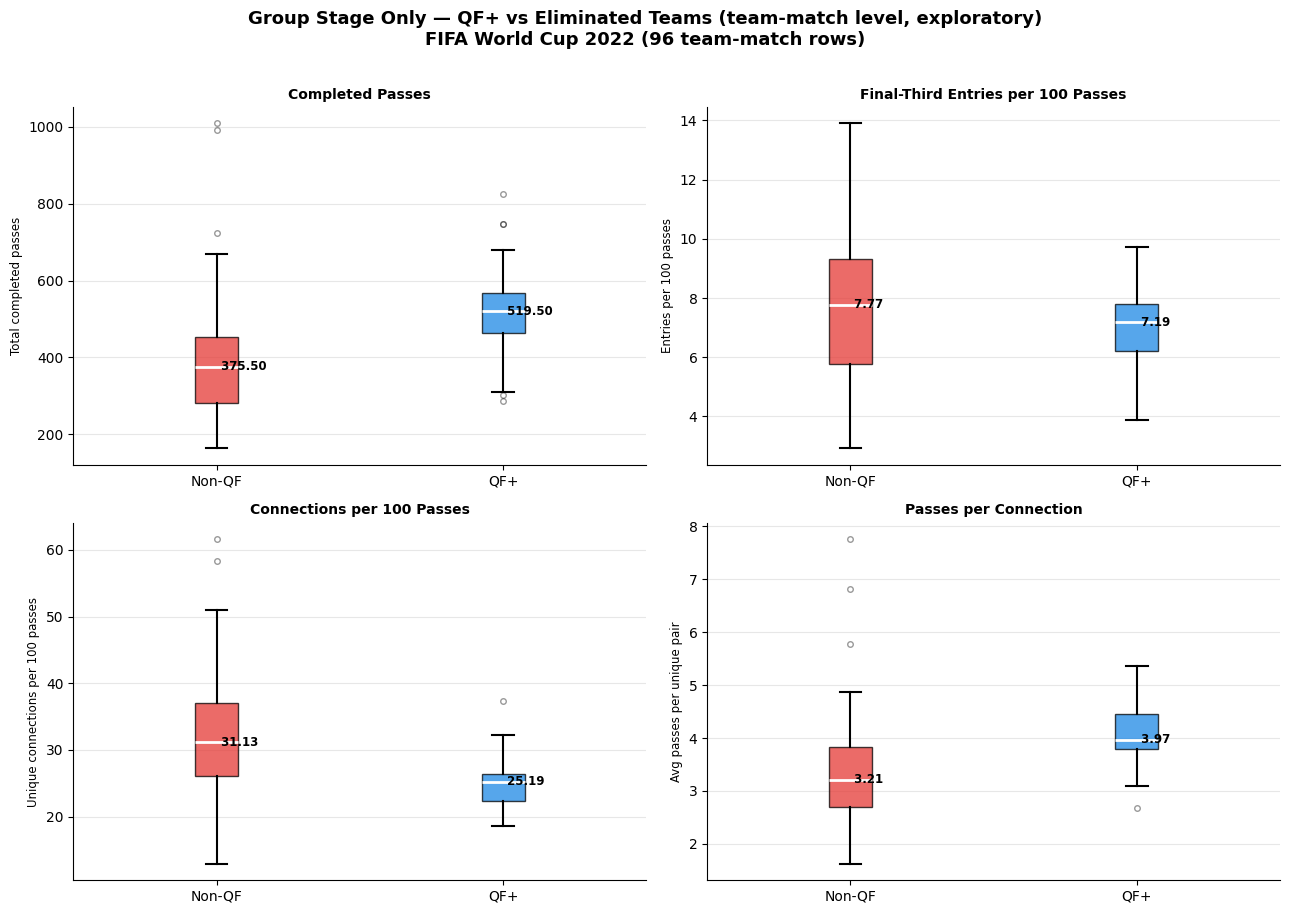

Saved: outputs/figures/05_group_stage_boxplots.png


In [13]:
QF_COLOR  = '#1E88E5'
ELM_COLOR = '#E53935'

def boxplot(ax, col, title, ylabel=None):
    """Single styled boxplot comparing non-QF vs QF+ for a given column."""
    bp = ax.boxplot(
        [non_gs[col].dropna(), qf_gs[col].dropna()],
        labels=['Non-QF', 'QF+'],
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=4, alpha=0.4),
    )
    for patch, color in zip(bp['boxes'], [ELM_COLOR, QF_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for i, vals in enumerate([non_gs[col], qf_gs[col]]):
        med = vals.dropna().median()
        ax.text(i + 1, med, f' {med:.2f}', va='center', fontsize=8.5, fontweight='bold')
    ax.set_title(title, fontsize=10, fontweight='bold')
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=8.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    'Group Stage Only — QF+ vs Eliminated Teams (team-match level, exploratory)\nFIFA World Cup 2022 (96 team-match rows)',
    fontsize=13, fontweight='bold', y=1.01,
)

boxplot(axes[0, 0], 'completed_passes',
        'Completed Passes', 'Total completed passes')

boxplot(axes[0, 1], 'final_third_entries_per_100_passes',
        'Final-Third Entries per 100 Passes', 'Entries per 100 passes')

boxplot(axes[1, 0], 'connections_per_100_passes',
        'Connections per 100 Passes', 'Unique connections per 100 passes')

boxplot(axes[1, 1], 'passes_per_connection',
        'Passes per Connection', 'Avg passes per unique pair')

plt.tight_layout()
plt.savefig(FIG_DIR / '05_group_stage_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/05_group_stage_boxplots.png')

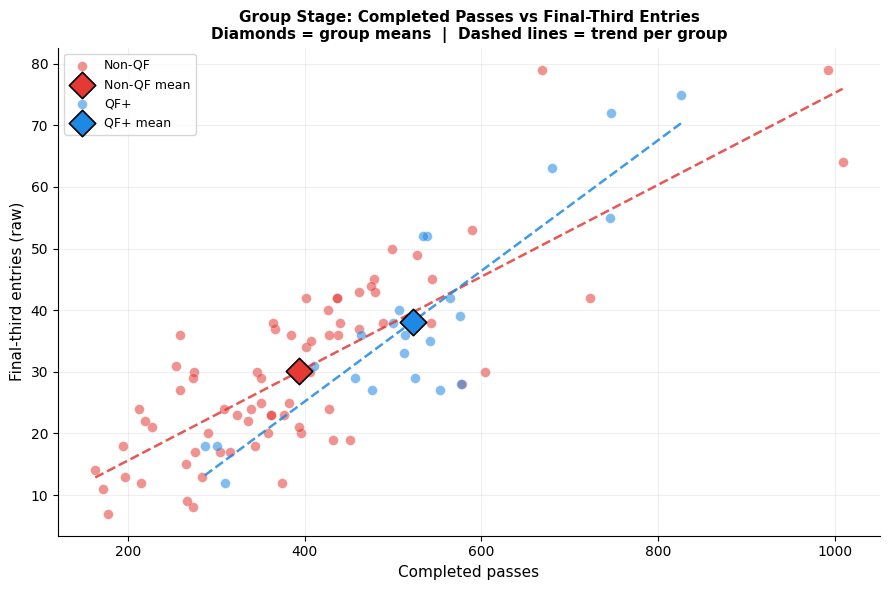

Saved: outputs/figures/05_group_stage_scatter.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 6))

for val, label, color in [(0, 'Non-QF', ELM_COLOR), (1, 'QF+', QF_COLOR)]:
    sub = gs[gs['reached_qf'] == val]
    ax.scatter(
        sub['completed_passes'], sub['final_third_entries'],
        c=color, alpha=0.55, s=50, label=label,
        edgecolors='white', linewidths=0.3,
    )
    sub_clean = sub.dropna(subset=['completed_passes', 'final_third_entries'])
    z = np.polyfit(sub_clean['completed_passes'], sub_clean['final_third_entries'], 1)
    x_line = np.linspace(sub_clean['completed_passes'].min(),
                         sub_clean['completed_passes'].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line),
            color=color, linewidth=1.8, linestyle='--', alpha=0.85)

    ax.scatter(
        sub['completed_passes'].mean(), sub['final_third_entries'].mean(),
        c=color, s=180, marker='D', edgecolors='black', linewidths=1.2,
        zorder=5, label=f'{label} mean',
    )

ax.set_xlabel('Completed passes', fontsize=11)
ax.set_ylabel('Final-third entries (raw)', fontsize=11)
ax.set_title(
    'Group Stage: Completed Passes vs Final-Third Entries\n'
    'Diamonds = group means  |  Dashed lines = trend per group',
    fontsize=11, fontweight='bold',
)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / '05_group_stage_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/05_group_stage_scatter.png')

## 5. Interpretation (team-match level, exploratory)

**Note:** this interpretation describes the exploratory, team-match-level results. For the
project's primary inferential conclusion, see the team-level analysis near the top of this
notebook.

### Did QF+ teams still complete more passes during the group stage?

Yes. The volume gap is already present in the group stage. QF+ teams averaged more completed passes per match than non-QF teams even before knockout rounds. The separation is visible in both the mean and median, and the scatter plot shows the QF+ mean diamond sitting noticeably to the right.

### Did QF+ teams still have more raw final-third entries?

Yes. QF+ teams generated more total final-third entries during the group stage. The scatter plot shows both a rightward (more passes) and upward (more entries) shift for QF+ teams relative to non-QF teams.

### Did QF+ teams have lower or higher final-third entries per 100 passes?

Lower — consistent with the full-dataset finding, though (as the team-level analysis shows) not statistically significant either way. When controlling for passing volume, non-QF teams converted a slightly higher share of their passes into final-third entries in this exploratory test.

### Did QF+ teams show more repeated passing relationships (higher passes per connection)?

Yes. The passes per connection gap is present in the group stage, and remains one of the few features that survives FDR correction at the team level too.

The team-match-level, group-stage-only results are broadly consistent with the team-level primary analysis above: quarterfinal teams completed substantially more passes, had denser networks, and generated more raw final-third entries even before knockout rounds began. However, only `completed_passes`, `connections_per_100_passes`, and `passes_per_connection` remain significant once the unit of analysis is corrected to one row per team and FDR-corrected — `unique_passing_pairs`, `network_density`, and `final_third_entries` are directionally consistent but not statistically confirmed at n=32 teams. Final-third entries per 100 passes and hub reliance are not significant differentiators in either version of the analysis. See the primary team-level section above for the project's main statistical conclusion, and notebook 13 for the same design applied to the 2018 tournament.